# Лабораторная работа №8
## Поиск трезвучий

по курсу Цифровая обработка сигналов

**направление**: Речевые технологии и машинное обучение

**преподаватель**: Рыбин Сергей Витальевич

**выполнил**: Юдин Артём Андреевич

**группа**: М4121


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

In [ ]:
def get_log_spec(wav: np.ndarray, sr: int = 16_000, n_fft: int = 8192) -> tuple:
    stft = librosa.stft(
        wav,
        n_fft=n_fft,
        hop_length=n_fft // 2,
        window=np.hanning(n_fft),
        center=True,
    )

    magnitude = np.abs(stft)
    avg_spectrum = np.mean(magnitude, axis=1)
    log_spec = 20 * np.log10(avg_spectrum + 1e-10)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    return freqs, log_spec


def find_main_peaks(
    freqs: np.ndarray,
    log_spec: np.ndarray,
    min_distance: int = 50,
    prominence: int = 10,
    hz_tol: int = 10,
) -> tuple[tuple, list]:
    peaks, _ = scipy.signal.find_peaks(
        log_spec,
        distance=min_distance,
        prominence=prominence,
    )

    peak_freqs = freqs[peaks]
    peak_mags = log_spec[peaks]

    # перебираем все комбинации из 3 пиков
    candidate_triads = []

    for i in range(len(peaks)):
        for j in range(i + 1, len(peaks)):
            for k in range(j + 1, len(peaks)):
                f1, f2, f3 = sorted([peak_freqs[i], peak_freqs[j], peak_freqs[k]])
                a1, a2, a3 = [peak_mags[idx] for idx in [i, j, k]]

                # интервалы в полутонах F1-F2 и F1-F3
                interval_12 = 12 * np.log2(f2 / f1)
                interval_13 = 12 * np.log2(f3 / f1)

                # терца: 3-4 и квинта: 7
                if not (2.5 <= interval_12 <= 4.5) or not (6.5 <= interval_13 <= 7.5):
                    continue

                # проверяем, что f3 не гармоника f1 или f2
                if abs(f3 - 2 * f1) < hz_tol or abs(f3 - 2 * f2) < hz_tol:
                    continue

                magnitude_sum = a1 + a2 + a3
                candidate_triads.append((magnitude_sum, (f1, f2, f3)))

    # выбираем комбинацию с максимальной суммой амплитуд
    best_triad = max(candidate_triads, key=lambda x: x[0])
    tone_freqs = best_triad[1]

    magnitudes = [peak_mags[np.argmin(abs(peak_freqs - freq))] for freq in tone_freqs]

    return tone_freqs, magnitudes


def get_tonality(freqs: tuple[float, float, float], F_0: float) -> str:
    notes = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

    # получаем полутона
    semitones = []
    for freq in freqs:
        shift = 12 * np.log2(freq / F_0)
        semitones.append(round(shift))

    # нормализуем и зануляем первый
    semitones.sort()
    base_shift = semitones[0]
    normalized = tuple(s - base_shift for s in semitones)

    match normalized:
        case (0, 4, 7):
            tonality_type = "major"
        case (0, 3, 7):
            tonality_type = "minor"
        case _:
            tonality_type = None

    note_index = base_shift % 12
    note = notes[note_index]

    return f"{note} {tonality_type}"


def check_overtones(
    freqs: np.ndarray,
    candidate_freqs: tuple,
    tolerance: float = 2.0,
) -> bool:
    for freq in candidate_freqs:
        for i in (1, 2):
            for harmonic_num in (2, 3):
                harmonic = i * harmonic_num * freq
                idx = np.argmin(np.abs(freqs - harmonic))

                # не звук струны
                if np.abs(freqs[idx] - harmonic) > tolerance:
                    return False
    return True

Тональность: E minor
Найденные частоты:
F1 (основной): 652.34 Гц
F2 (терцовый): 781.25 Гц
F3 (квинтовый): 970.70 Гц


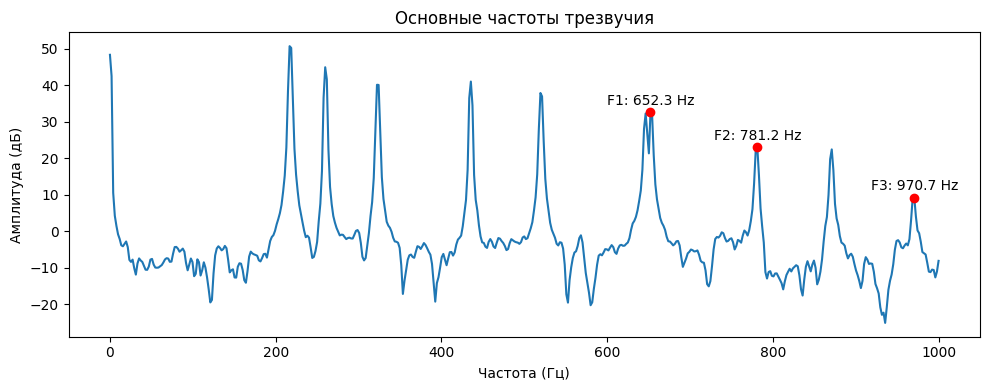

In [ ]:
F_0 = 130.82
SR = 16_000

wav, sr = librosa.load("DTLab14.wav", sr=SR)
freqs, log_spectrum = get_log_spec(wav, sr, n_fft=8192)
tone_freqs, magnitudes = find_main_peaks(freqs, log_spectrum, min_distance=50)

assert check_overtones(freqs, tone_freqs, tolerance=2), "У основных частот нет гармоник"

tonality = get_tonality(tone_freqs, F_0)

print(f"Тональность: {tonality}")
print("Найденные частоты:")
for note, freq in zip(["F1 (основной)", "F2 (терцовый)", "F3 (квинтовый)"], tone_freqs):
    print(f"{note}: {freq:.2f} Гц")

max_freq = 1
while max_freq - tone_freqs[-1] < 0:
    max_freq *= 10

freq_idx = np.argmax(freqs > max_freq)

plt.figure(figsize=(10, 4))
plt.plot(freqs[:freq_idx], log_spectrum[:freq_idx])
plt.scatter(tone_freqs, magnitudes, color="red", zorder=5)

for i, (f, a) in enumerate(zip(tone_freqs, magnitudes), 1):
    plt.text(f, a + 2, f"F{i}: {f:.1f} Hz", ha="center")

plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда (дБ)")
plt.title("Основные частоты трезвучия")

plt.tight_layout()
plt.show()
